In [1]:
!pip install scikit-image scipy matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 22.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.4/315.4 KB 8.5 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 20.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 13.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.9/220.9 KB 7.8 MB/s eta 0:00:00


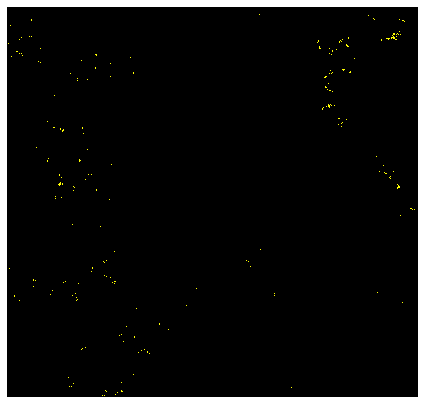

Individual hotspot areas:
 Label  Area_px  Area_um2
     1      1.0    0.1024
     2      1.0    0.1024
     3      4.0    0.4096
     4      3.0    0.3072
     5     27.0    2.7648
     6      2.0    0.2048
     7      1.0    0.1024
     8      1.0    0.1024
     9      1.0    0.1024
    10     11.0    1.1264
    11      1.0    0.1024
    12     43.0    4.4032
    13      4.0    0.4096
    14      3.0    0.3072
    15      5.0    0.5120
    16      1.0    0.1024
    17      2.0    0.2048
    18      5.0    0.5120
    19      4.0    0.4096
    20     55.0    5.6320
    21      8.0    0.8192
    22      5.0    0.5120
    23      9.0    0.9216
    24      2.0    0.2048
    25      2.0    0.2048
    26      1.0    0.1024
    27      6.0    0.6144
    28     65.0    6.6560
    29      5.0    0.5120
    30      2.0    0.2048
    31      5.0    0.5120
    32      1.0    0.1024
    33     56.0    5.7344
    34      5.0    0.5120
    35      1.0    0.1024
    36     15.0    1.5360
    37     1

In [36]:
from skimage import io, filters, measure
from scipy.spatial import cKDTree
from scipy.ndimage import gaussian_filter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === file and analysis variables ===
img_path   = "WT-HDM-20X-tilescans_Merged_Crop001.tif"
um_per_pix = 0.32
radius_um  = 10.0
sigma      = 1
perc       = 98

# 1. Load and split RGB channels
img = io.imread(img_path)
red, blue = img[...,0], img[...,2]
h, w = red.shape

# 2. Segment C3+ vs. GATA3+
r_thr = filters.threshold_otsu(red)
b_thr = filters.threshold_otsu(blue)
fib = (red > r_thr) & (blue <= b_thr)
gat = (red > r_thr) & (blue >  b_thr)

# 3. Calculate centroids
fib_cent = np.array([p.centroid for p in measure.regionprops(measure.label(fib))])
gat_cent = np.array([p.centroid for p in measure.regionprops(measure.label(gat))])

# 4. Find interacting pairs within radius_um
dist_px = radius_um / um_per_pix
tree    = cKDTree(gat_cent)
pairs   = [(i,j)
           for i, js in enumerate(tree.query_ball_point(fib_cent, r=dist_px))
           for j in js]

# 5. Build midpoint histogram
H = np.zeros((h, w), float)
for i, j in pairs:
    y1, x1 = fib_cent[i]
    y2, x2 = gat_cent[j]
    yi, xi = int(round((y1 + y2)/2)), int(round((x1 + x2)/2))
    if 0 <= yi < h and 0 <= xi < w:
        H[yi, xi] += 1

# 6. Smooth & threshold
D    = gaussian_filter(H, sigma=sigma)
pos  = D[D>0]
thr  = np.percentile(pos, perc)
mask = D > thr

# 7. Build hotspot canvas and display
canvas = np.zeros((h, w, 3), dtype=np.uint8)
canvas[mask, 0] = 255  # yellow R
canvas[mask, 1] = 255  # yellow G

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(canvas, interpolation='none')
ax.axis('off')
plt.tight_layout()

# 8. Save image
out_path = "/Users/stephanelajoie/Library/CloudStorage/Dropbox/C3_fibros_paper/NEW/Figures/EVEN NEWER/HOTSPOT_analysis/hotspot_maps.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

# 9. Label hotspots & compute metrics
lbl_hot = measure.label(mask)
props   = measure.regionprops(lbl_hot)

# Build DataFrame of individual hotspot areas
rows = []
for p in props:
    area_px  = p.area
    area_um2 = area_px * (um_per_pix**2)
    rows.append({
        "Label":      p.label,
        "Area_px":    area_px,
        "Area_um2":   area_um2
    })
df = pd.DataFrame(rows)

# 10. Compute summary statistics
summary = {
    "n_hotspots":      len(props),
    "total_area_um2":  df["Area_um2"].sum(),
    "percent_area":    df["Area_px"].sum() / (h*w) * 100,
    "mean_area_um2":   df["Area_um2"].mean() if len(df) else 0,
    "median_area_um2": df["Area_um2"].median() if len(df) else 0
}
df_summary = pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])

# 11. Display metrics
print("Individual hotspot areas:")
print(df.to_string(index=False))
print("\nSummary statistics:")
print(df_summary)

# (Optional) save to CSV
df.to_csv("/Users/stephanelajoie/Library/CloudStorage/Dropbox/C3_fibros_paper/NEW/Figures/EVEN NEWER/HOTSPOT_analysis/hotspot_regions.csv", index=False)
df_summary.to_csv("/Users/stephanelajoie/Library/CloudStorage/Dropbox/C3_fibros_paper/NEW/Figures/EVEN NEWER/HOTSPOT_analysis/hotspot_summary.csv")


